In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

In [4]:
X, y = iris.data, iris.target  # type:ignore

In [5]:
X_ = pd.DataFrame(
    X,
    columns=iris["feature_names"], # type: ignore
)

In [6]:
X_["target"] = y

In [7]:
X_.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X[:, [2, 3]], y, test_size=0.2, random_state=1
)

In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

In [11]:
nb = GaussianNB()
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [12]:
y_pred = nb.predict(X_test)

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [14]:
from mlxtend.plotting import plot_decision_regions

ModuleNotFoundError: No module named 'mlxtend'

<Axes: >

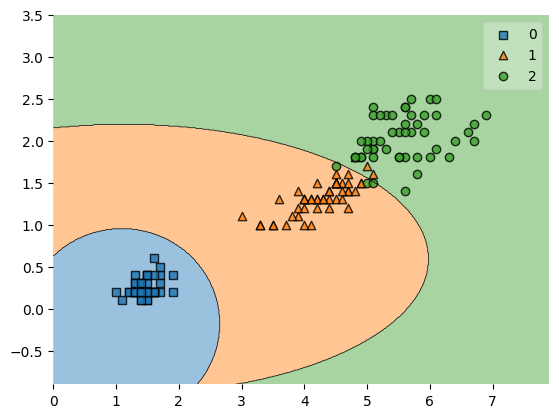

In [ ]:
plot_decision_regions(X[:,[2,3]], y, nb)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [ ]:
dt = DecisionTreeClassifier(criterion="entropy")
dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred = dt.predict(X_test)


In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [15]:
from mlxtend.plotting import plot_decision_regions

ModuleNotFoundError: No module named 'mlxtend'

<Axes: >

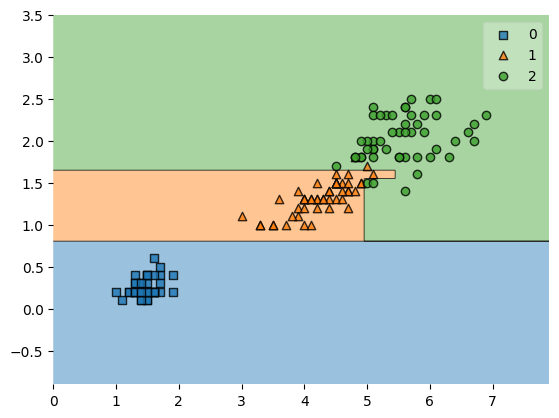

In [ ]:
plot_decision_regions(X[:, [2, 3]], y, dt)

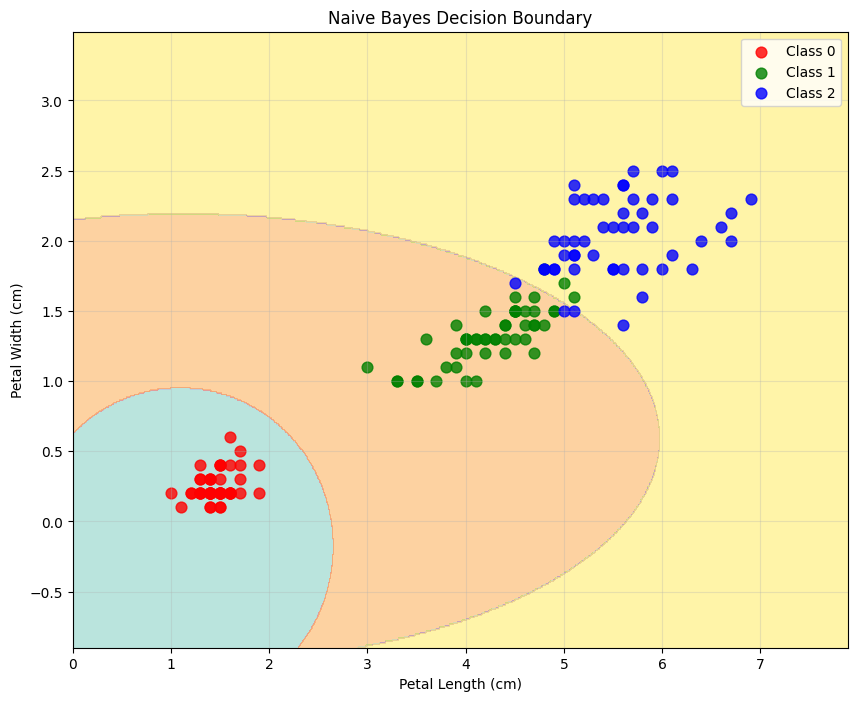

NameError: name 'dt' is not defined

In [16]:
import matplotlib.pyplot as plt

def plot_decision_boundary_manual(X, y, model, title="Decision Boundary"):
    # Create a mesh to plot the decision boundary
    h = 0.01  # step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Make predictions on the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Set3)
    
    # Plot the data points
    colors = ['red', 'green', 'blue']
    for i in range(len(np.unique(y))):
        plt.scatter(X[y == i, 0], X[y == i, 1], 
                   c=colors[i], label=f'Class {i}', s=60, alpha=0.8)
    
    plt.xlabel('Petal Length (cm)')
    plt.ylabel('Petal Width (cm)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot for Naive Bayes
plot_decision_boundary_manual(X[:, [2, 3]], y, nb, "Naive Bayes Decision Boundary")

# Plot for Decision Tree  
plot_decision_boundary_manual(X[:, [2, 3]], y, dt, "Decision Tree Decision Boundary")